# Lab 24: Bar Charts - Data Visualization
## IBM Data Analytics Capstone Project 
### Objective: Visualize distributions, relationships, compositions and comparisons using bar charts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

age_mapping = {
    'Under 18 years old': 16, '18-24 years old': 21,
    '25-34 years old': 29, '35-44 years old': 39,
    '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 70
}
age_order = list(age_mapping.keys())
df['Age_Numeric'] = df['Age'].map(age_mapping)

print("Dataset loaded! Shape:", df.shape)

Dataset loaded! Shape: (65437, 115)


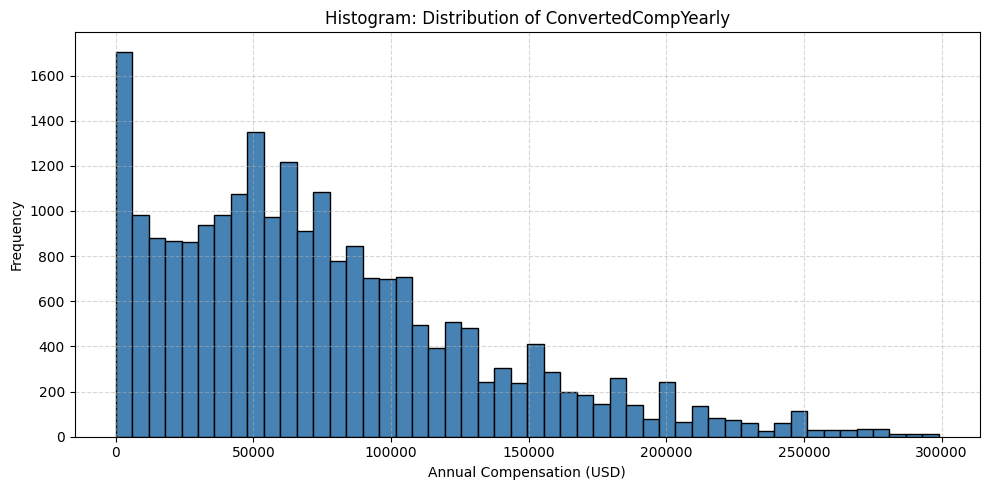

Histogram saved!


In [2]:
comp_data = df['ConvertedCompYearly'].dropna()
comp_data = comp_data[comp_data < 300000]

plt.figure(figsize=(10, 5))
plt.hist(comp_data, bins=50, color='steelblue', edgecolor='black')
plt.title('Histogram: Distribution of ConvertedCompYearly')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('hist_comp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Histogram saved!")

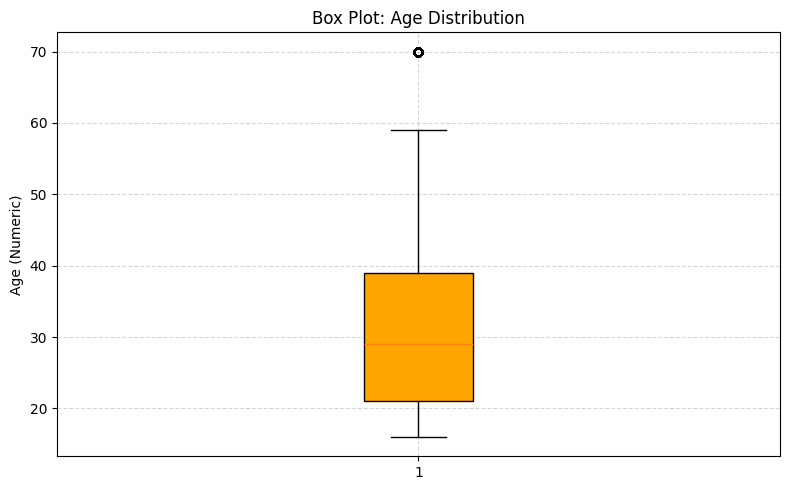

Box plot saved!
count    65115.000000
mean        32.641772
std         11.140749
min         16.000000
25%         21.000000
50%         29.000000
75%         39.000000
max         70.000000
Name: Age_Numeric, dtype: float64


In [7]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['Age_Numeric'].dropna(), patch_artist=True,
            boxprops=dict(facecolor='orange', color='black'))
plt.title('Box Plot: Age Distribution')
plt.ylabel('Age (Numeric)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('boxplot_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Box plot saved!")
print(df['Age_Numeric'].describe())

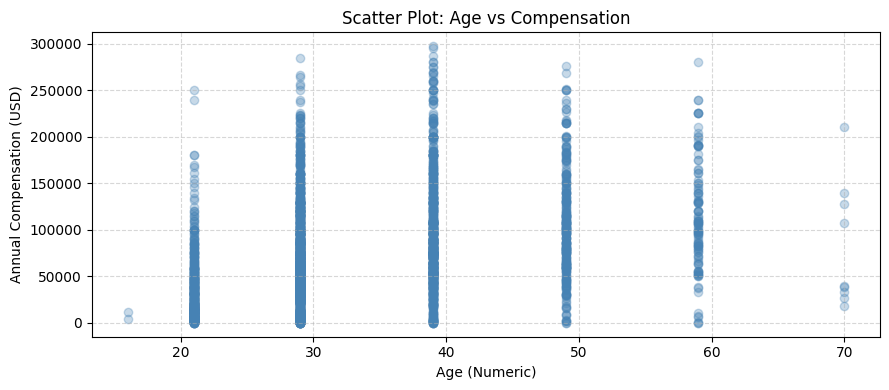

Scatter plot saved!


In [6]:
sample = df[['Age_Numeric', 'ConvertedCompYearly']].dropna()
sample = sample[sample['ConvertedCompYearly'] < 300000].sample(3000, random_state=42)

plt.figure(figsize=(9, 4))
plt.scatter(sample['Age_Numeric'], sample['ConvertedCompYearly'],
            alpha=0.3, color='steelblue')
plt.title('Scatter Plot: Age vs Compensation')
plt.xlabel('Age (Numeric)')
plt.ylabel('Annual Compensation (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('scatter_age_comp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved!")

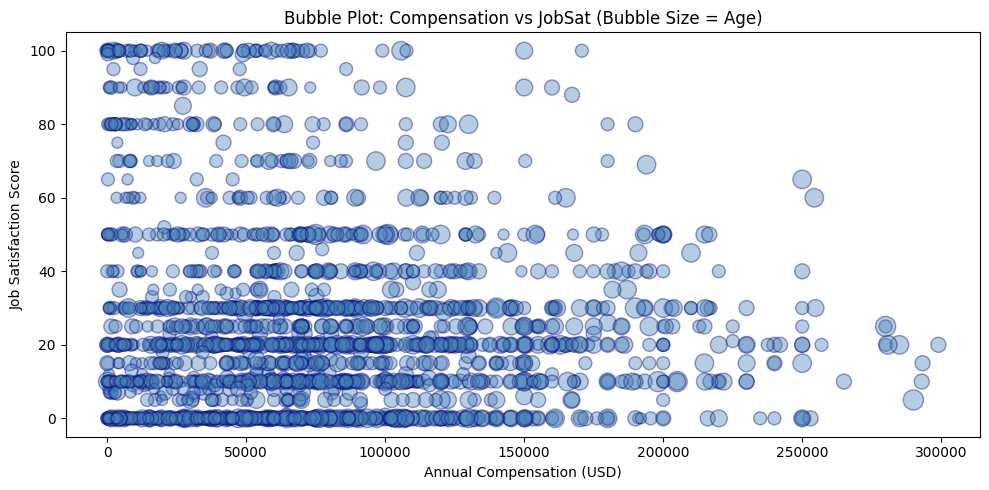

Bubble plot saved!


In [9]:
sample = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age_Numeric']].dropna()
sample = sample[sample['ConvertedCompYearly'] < 300000].sample(2000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample['ConvertedCompYearly'], sample['JobSatPoints_6'],
            s=sample['Age_Numeric'] * 3,
            alpha=0.4, color='steelblue', edgecolors='navy')
plt.title('Bubble Plot: Compensation vs JobSat (Bubble Size = Age)')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Job Satisfaction Score')
plt.tight_layout()
plt.savefig('bubble_comp_jobsat_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bubble plot saved!")

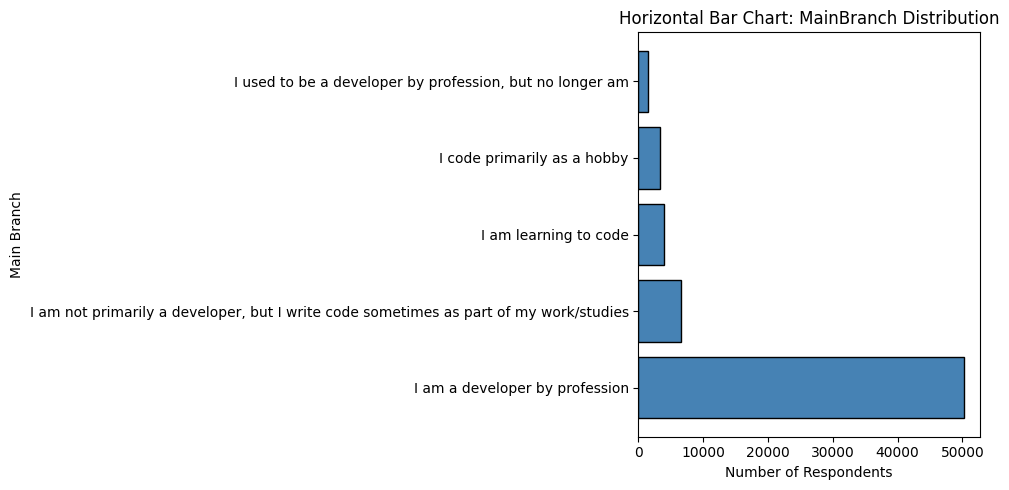

 MainBranch bar chart saved!


In [10]:
mainbranch = df['MainBranch'].value_counts()

plt.figure(figsize=(10, 5))
plt.barh(mainbranch.index, mainbranch.values, color='steelblue', edgecolor='black')
plt.title('Horizontal Bar Chart: MainBranch Distribution')
plt.xlabel('Number of Respondents')
plt.ylabel('Main Branch')
plt.tight_layout()
plt.savefig('bar_mainbranch.png', dpi=150, bbox_inches='tight')
plt.show()
print(" MainBranch bar chart saved!")

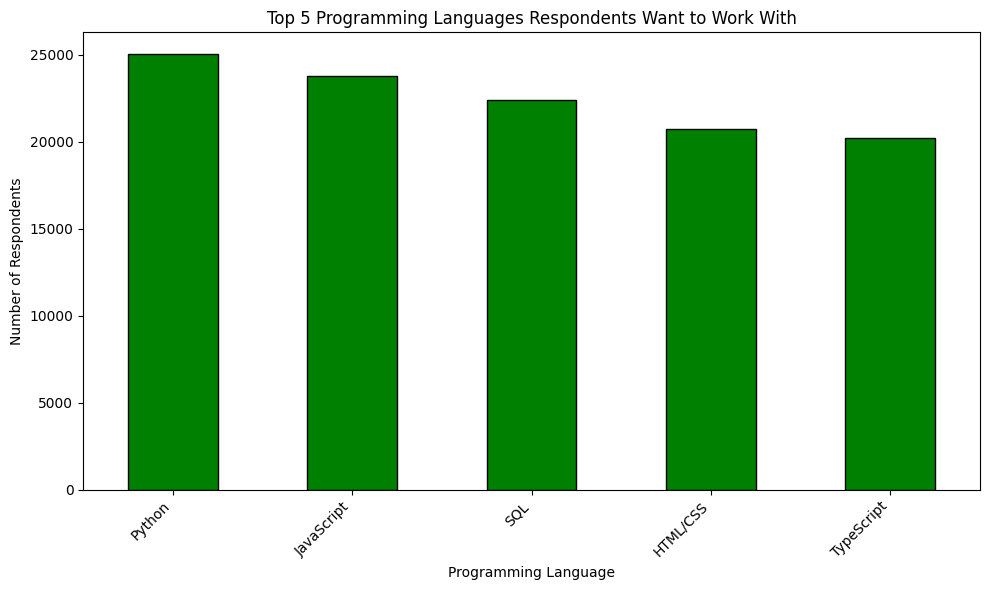

Top 5 languages saved!
LanguageWantToWorkWith
Python        25047
JavaScript    23774
SQL           22400
HTML/CSS      20721
TypeScript    20239
Name: count, dtype: int64


In [12]:
top5_langs = df['LanguageWantToWorkWith'].dropna().str.split(';').explode().value_counts().head(5)

plt.figure(figsize=(10, 6))
top5_langs.plot(kind='bar', color='green', edgecolor='black')
plt.title('Top 5 Programming Languages Respondents Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bar_top5_languages.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top 5 languages saved!")
print(top5_langs)

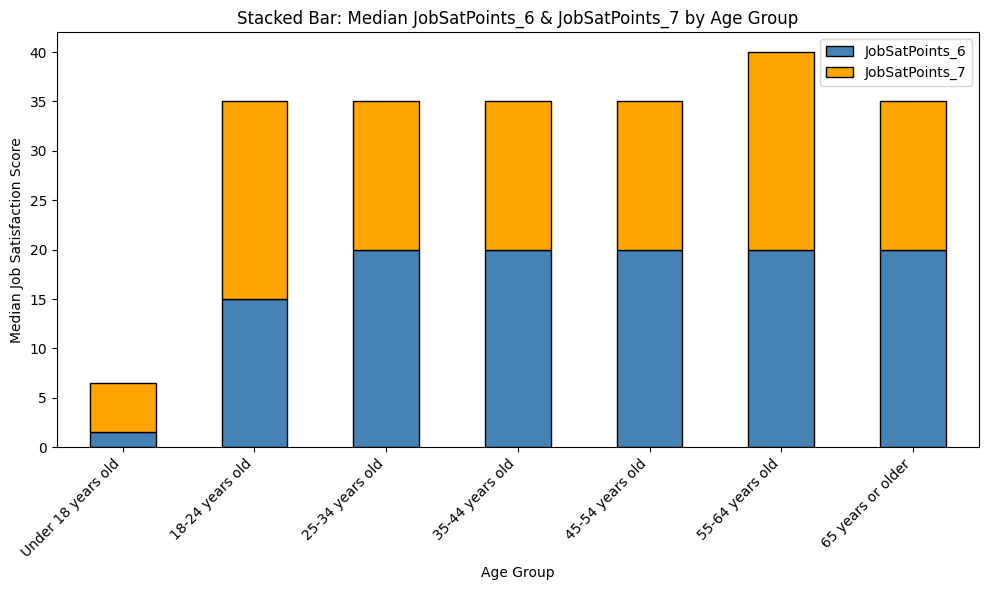

Stacked JobSat by age saved!


In [14]:
df_age_sat = df.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median().reindex(age_order).dropna()

ax = df_age_sat.plot(kind='bar', stacked=True, figsize=(10, 6),
                     color=['steelblue', 'orange'], edgecolor='black')
plt.title('Stacked Bar: Median JobSatPoints_6 & JobSatPoints_7 by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Job Satisfaction Score')
plt.xticks(rotation=45, ha='right')
plt.legend(['JobSatPoints_6', 'JobSatPoints_7'])
plt.tight_layout()
plt.savefig('stacked_jobsat_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Stacked JobSat by age saved!")

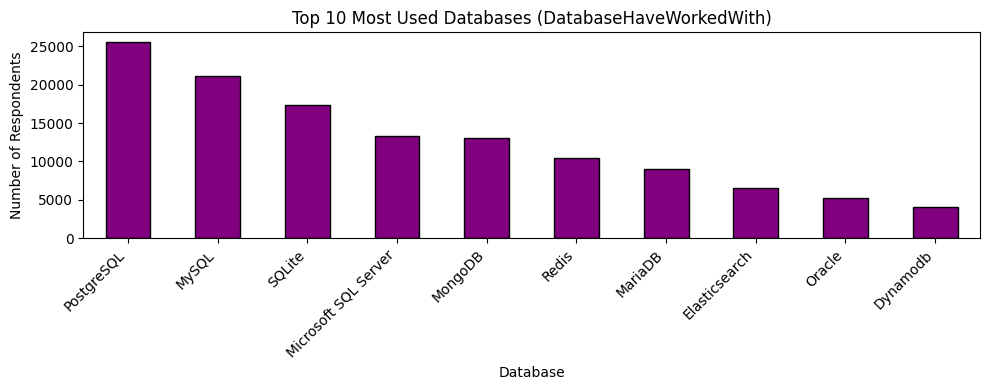

Database popularity saved!
DatabaseHaveWorkedWith
PostgreSQL              25536
MySQL                   21099
SQLite                  17365
Microsoft SQL Server    13275
MongoDB                 13007
Redis                   10463
MariaDB                  8991
Elasticsearch            6533
Oracle                   5273
Dynamodb                 4138
Name: count, dtype: int64


In [15]:
top10_db = df['DatabaseHaveWorkedWith'].dropna().str.split(';').explode().value_counts().head(10)

plt.figure(figsize=(10, 4))
top10_db.plot(kind='bar', color='purple', edgecolor='black')
plt.title('Top 10 Most Used Databases (DatabaseHaveWorkedWith)')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bar_databases.png', dpi=150, bbox_inches='tight')
plt.show()
print("Database popularity saved!")
print(top10_db)

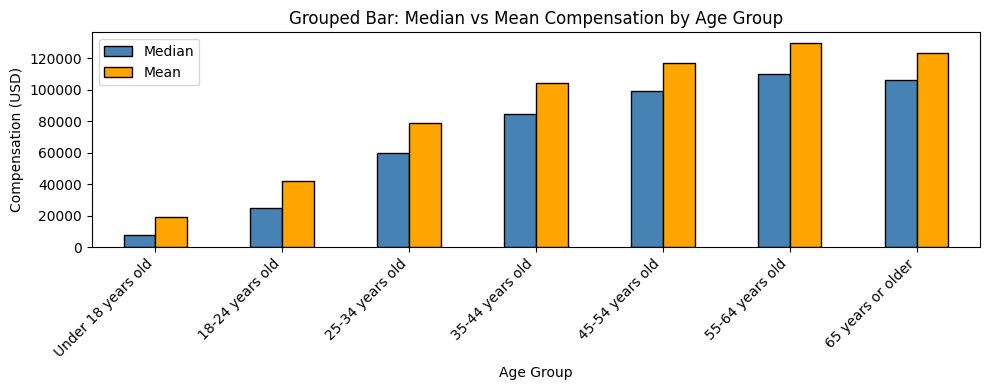

Grouped bar compensation saved!


In [16]:
df_comp_age = df.groupby('Age')['ConvertedCompYearly'].agg(['median', 'mean']).reindex(age_order).dropna()

ax = df_comp_age.plot(kind='bar', figsize=(10, 4),
                      color=['steelblue', 'orange'], edgecolor='black')
plt.title('Grouped Bar: Median vs Mean Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Compensation (USD)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Median', 'Mean'])
plt.tight_layout()
plt.savefig('grouped_bar_comp_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grouped bar compensation saved!")

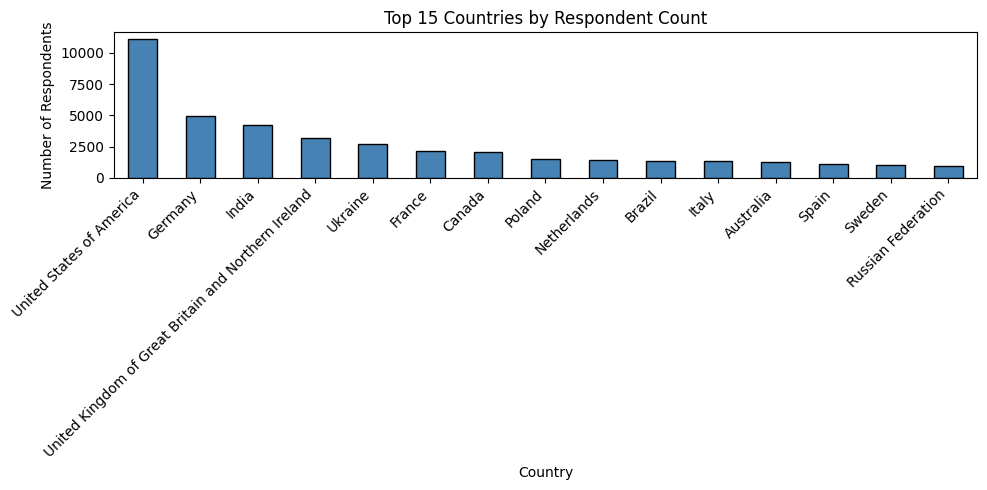

Countries bar chart saved!


In [18]:
top15_countries = df['Country'].value_counts().head(15)

plt.figure(figsize=(10, 5))
top15_countries.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Countries by Respondent Count')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bar_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Countries bar chart saved!")